# MLP for MNIST

Let's see how to build and train a MLP, with Keras and tensorflow, for the MNIST data set.

based on:  
https://keras.io/examples/vision/mnist_convnet/  
and  
https://colab.research.google.com/github/trekhleb/machine-learning-experiments/blob/master/experiments/digits_recognition_mlp/digits_recognition_mlp.ipynb

june 2022, hdaniel@ualg.pt
Update March 10, 2025, jvo@ualg.pt

## Step 1: Load the MNIST dataset and normalize

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test  = x_test.astype("float32")  / 255

# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# convert class vectors to binary class matrices (one hot encoded)
y_train_class = y_train # preserver for plo below
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

#Display layout
print("x_train shape:", x_train.shape)
print("y_labels shape (one hot):", y_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0],  "test samples")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train shape: (60000, 28, 28, 1)
y_labels shape (one hot): (60000, 10)
60000 train samples
10000 test samples


### Let's see part of the MNIST data set

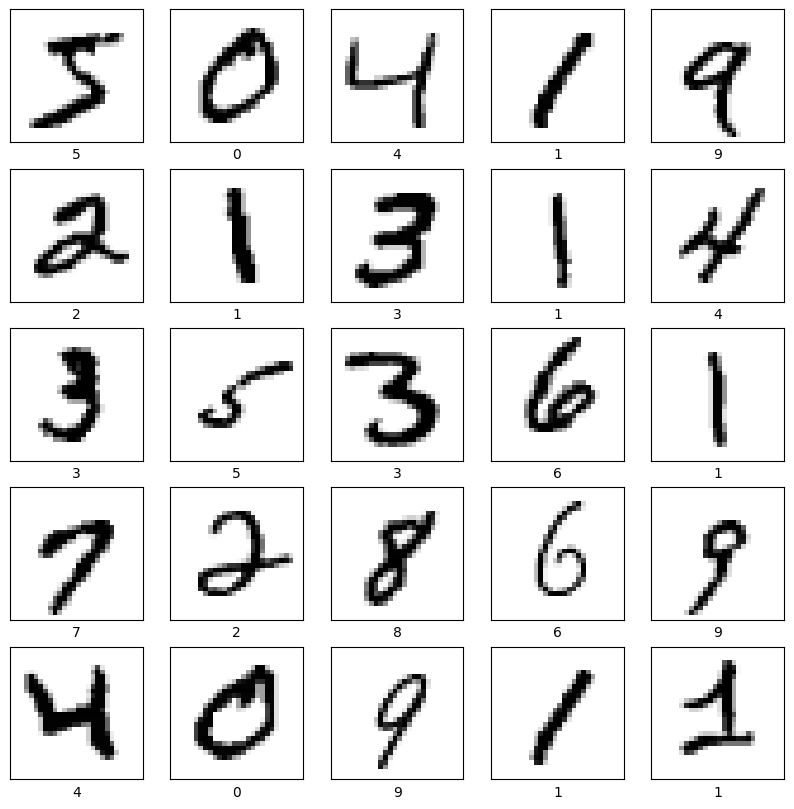

In [3]:
numbers_to_display = 25
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(10,10))
for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train_class[i])
plt.show()

## Step 2: Create the MLP model

In [4]:
l2reg = 0.002
neurons1 = 128
neurons2 = 128

model = keras.Sequential([
  layers.Flatten(input_shape=(28, 28)),
  layers.Dense(neurons1, activation='relu', kernel_regularizer=keras.regularizers.l2(l2reg)),
  layers.Dense(neurons1, activation='relu', kernel_regularizer=keras.regularizers.l2(l2reg)),
  layers.Dense(num_classes, activation="softmax")
])

'''
#OR:

model = keras.Sequential()
# Input layers.
model.add(layers.Flatten(input_shape=input_shape[:2]))
model.add(layers.Dense(
    units=neurons1,
    activation=tf.keras.activations.relu,
    kernel_regularizer=keras.regularizers.l2(l2reg)
))

# Hidden layers.
model.add(layers.Dense(
    units=neurons2,
    activation=tf.keras.activations.relu,
    kernel_regularizer=keras.regularizers.l2(l2reg)
))

# Output layers.
model.add(layers.Dense(
    units=10,
    activation=keras.activations.softmax
))
'''

model.summary()

/Users/compl3x/Programations/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train the  model

In [5]:
batch_size = 128
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

'''
Or:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
)
'''

training_history=model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - accuracy: 0.8985 - loss: 0.7164 - val_accuracy: 0.9552 - val_loss: 0.4184
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.9494 - loss: 0.3887 - val_accuracy: 0.9597 - val_loss: 0.3182
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9580 - loss: 0.3064 - val_accuracy: 0.9698 - val_loss: 0.2625
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - accuracy: 0.9645 - loss: 0.2631 - val_accuracy: 0.9728 - val_loss: 0.2337
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.9667 - loss: 0.2418 - val_accuracy: 0.9712 - val_loss: 0.2284
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.9683 - loss: 0.2252 - val_accuracy: 0.9748 - val_loss: 0.2112
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.9704 - loss: 0.2153 - val_accuracy: 0.9760 - val_loss: 0.1993
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.9712 - loss: 0.2068 - 

## Step 4: Evaluate the  model

In [6]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.1915319710969925
Test accuracy: 0.972599983215332


### Loss function evolution during the training

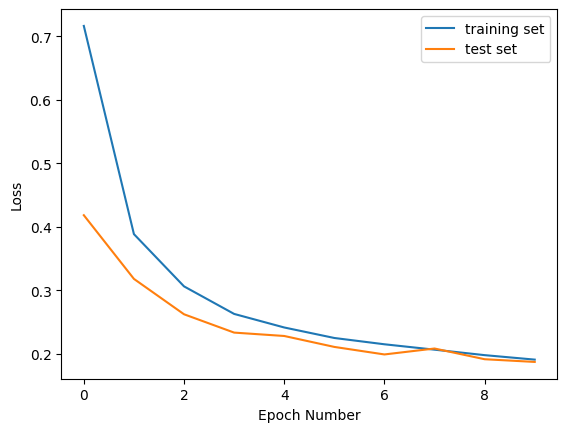

In [7]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

### Accuracy evolution during the training

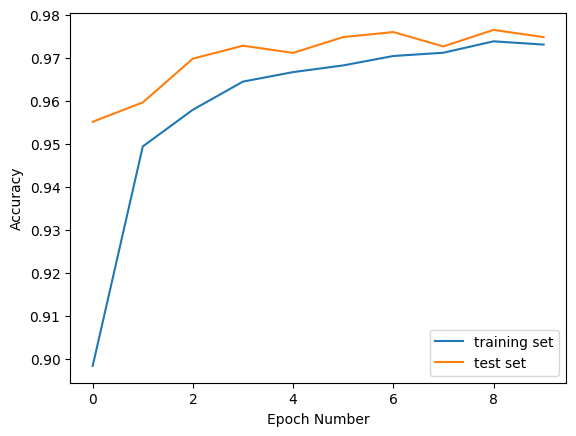

In [8]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

## Step 5: Use the model to predict

Use the model just trained for digits recognition, with`predict()` method.

For each each item in the set, there are a prediction with 10 probabilities, since it was one hot enconded to 10 classes (digits): 0 to 9.
The digit with the highest probability is the one the model is most confident with.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step
Number of items to predict: 10000
One hot encoded prediction: [6.9530606e-06 3.3314653e-05 1.6066348e-04 4.2745462e-04 1.5608040e-07
 3.4311877e-05 2.7848694e-08 9.9926484e-01 2.5726733e-05 4.6707337e-05]

Digit predicted: 7


/Users/compl3x/Programations/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 28, 28, 1))',)
  warnings.warn(msg)
/Users/compl3x/Programations/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 28, 28, 1))',)
  warnings.warn(msg)


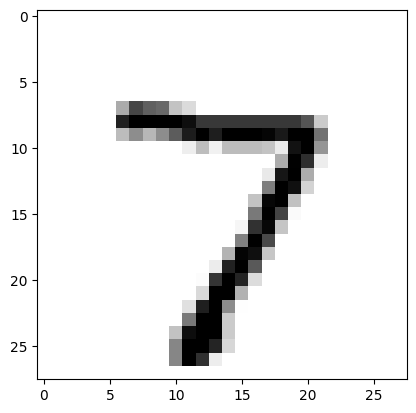

In [9]:
predictions_one_hot = model.predict([x_test])
print('Number of items to predict:', predictions_one_hot.shape[0])
print('One hot encoded prediction:', predictions_one_hot[0])

# Find the highest predicted digit for every perdiction
predictions = np.argmax(predictions_one_hot, axis=1)
print('\nDigit predicted:', predictions[0])

# Check if digit at index 0 was correctly predicted
plt.imshow(x_test[0], cmap=plt.cm.binary)
plt.show()

### Check several predictions
Each image has the prediction below. If the prediction is wrong it will be printed in red.

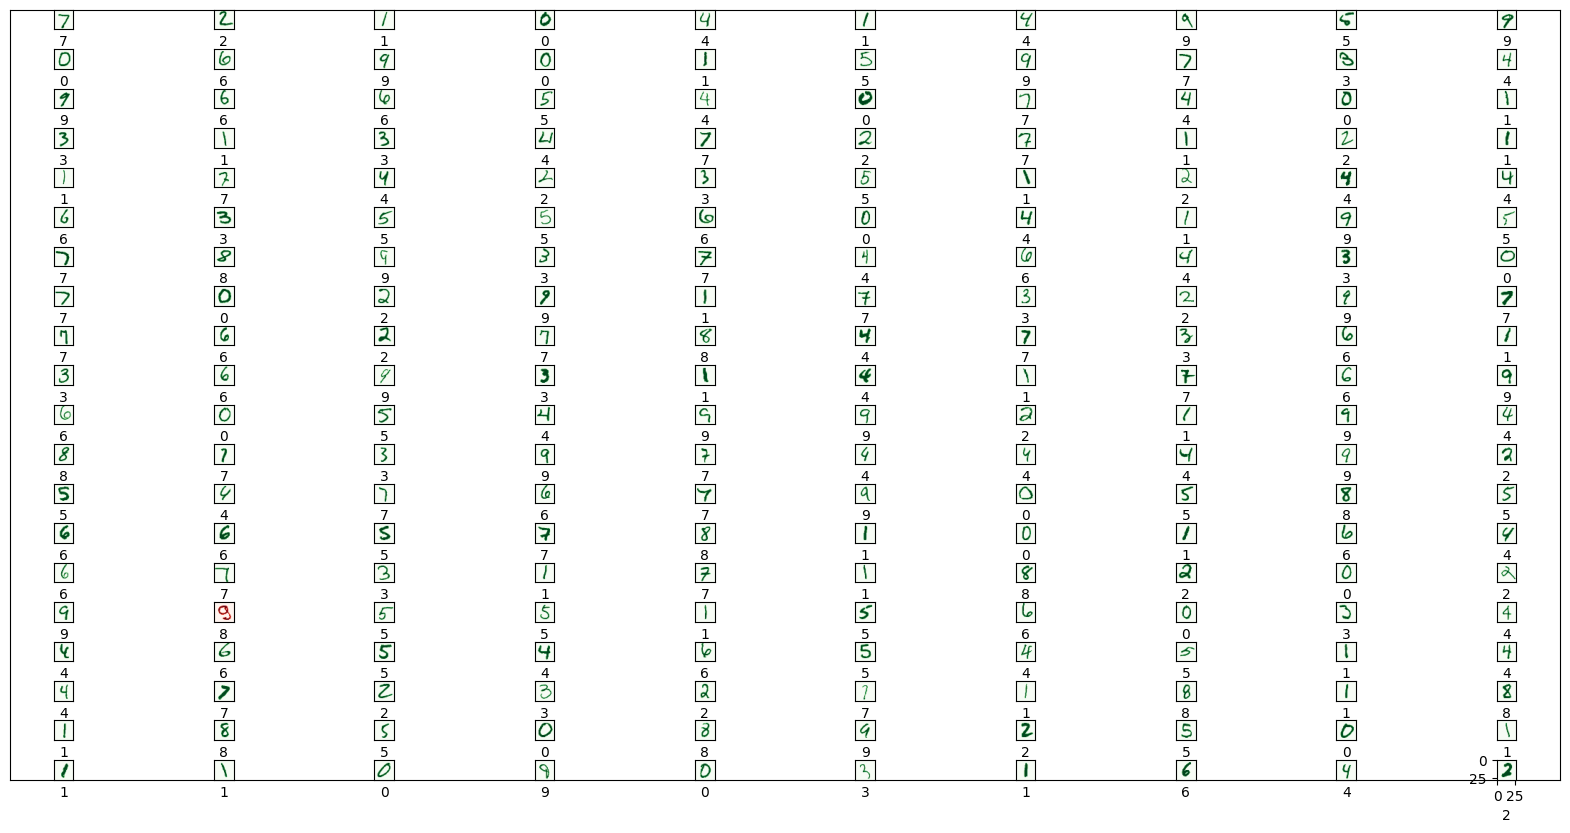

In [10]:
table_rows = 20
table_cols = 10
numbers_to_display = table_rows * table_cols
plt.figure(figsize=(table_rows, table_cols))
labels = np.argmax(y_test, axis=1)  # decode

for plot_index in range(numbers_to_display):
    predicted_label = predictions[plot_index]
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    color_map = 'Greens' if predicted_label == labels[plot_index] else 'Reds'
    plt.subplot(table_rows, table_cols, plot_index + 1)
    plt.imshow(x_test[plot_index], cmap=color_map)
    plt.xlabel(predicted_label)

plt.subplots_adjust(hspace=1, wspace=0.5)
plt.show()

# Confusion matrix

A [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) shows what digits are well identified and the ones the model confuses.

The confusion matrix has shape n x n, where n is the number of classes. The rows represent the **real** labels and the **columns** the predicted labels. The main diagonal represents the correct prediction. Above are the false negatives and below the false positives.    
[tf.mathconfusion_matrix](https://www.tensorflow.org/api_docs/python/tf/math/confusion_matrix) function parameters `labels` and `predictions` must be 1-D arrays of the same shape.


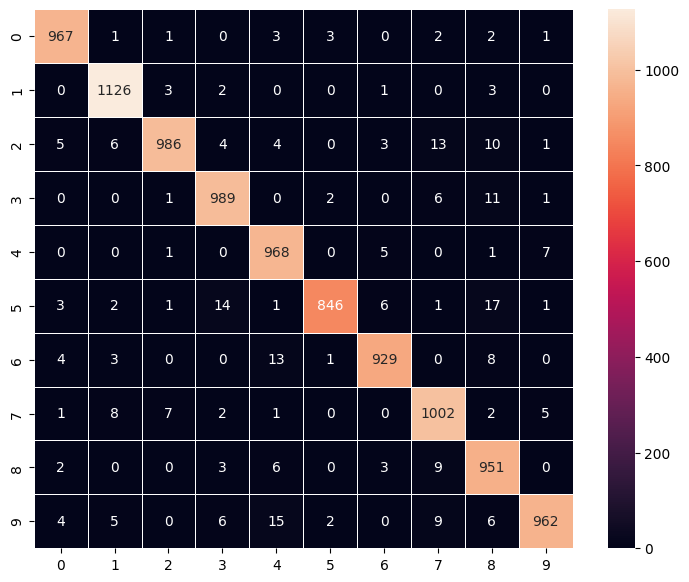

In [11]:
confusion_matrix = tf.math.confusion_matrix(labels, predictions)
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

## Further readings

https://colab.research.google.com/github/trekhleb/machine-learning-experiments/blob/master/experiments/digits_recognition_mlp/digits_recognition_mlp.ipynb